## Model Performance Summary

### Logistic Regression
- AUC: 0.7412
- KS: 0.3618

### XGBoost
- AUC: 0.7390

### Key Insights
- Logistic Regression slightly outperformed XGBoost
- WOE transformation improved interpretability
- Model demonstrates good discriminatory power
- Traditional scorecard models remain highly effective in credit risk analytics

In [7]:
# ============================================================
# STEP 1 — IMPORT LIBRARIES
# ============================================================

!pip install scorecardpy

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import scorecardpy as sc

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

pd.set_option('display.max_columns', None)

In [8]:
# ============================================================
# STEP 2 — LOAD CLEANED DATA
# ============================================================

df = pd.read_csv('/content/cleaned_application_train.csv')

df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,LANDAREA_MODE,LIVINGAREA_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,LANDAREA_MEDI,LIVINGAREA_MEDI,NONLIVINGAREA_MEDI,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,AGE_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,EMPLOYMENT_YEARS,CREDIT_TERM
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.00,0.0690,0.0833,0.0369,0.0190,0.0000,0.0252,0.0383,0.9722,0.0000,0.0690,0.0833,0.0377,0.0198,0.0000,0.0250,0.0369,0.9722,0.00,0.0690,0.0833,0.0375,0.0193,0.0000,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0,25.920548,2.007889,0.121978,1.745205,16.461104
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,0.535276,0.0959,0.0529,0.9851,0.08,0.0345,0.2917,0.0130,0.0549,0.0098,0.0924,0.0538,0.9851,0.0806,0.0345,0.2917,0.0128,0.0554,0.0000,0.0968,0.0529,0.9851,0.08,0.0345,0.2917,0.0132,0.0558,0.0100,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,45.931507,4.790750,0.132217,3.254795,36.234085
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,0.505998,0.555912,0.729567,0.0876,0.0763,0.9816,0.00,0.1379,0.1667,0.0481,0.0745,0.0036,0.0840,0.0746,0.9816,0.0000,0.1379,0.1667,0.0458,0.0731,0.0011,0.0864,0.0758,0.9816,0.00,0.1379,0.1667,0.0487,0.0749,0.0031,Missing,0.0688,Missing,Missing,0.0,0.0,0.0,0.0,-815.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,52.180822,2.000000,0.100000,0.616438,20.000000
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / 

In [9]:
# ============================================================
# STEP 3 — TRAIN TEST SPLIT
# ============================================================

train, test = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df['TARGET']
)

print(train.shape)
print(test.shape)

(215257, 110)
(92254, 110)


In [10]:
# ============================================================
# STEP 4 — VARIABLE FILTERING
# ============================================================

dt_s = sc.var_filter(
    train,
    y='TARGET'
)

print(dt_s.shape)

[INFO] filtering variables ...
Variable filtering on 215257 rows and 110 columns in 00:06:08 
50 variables are removed
(215257, 60)


In [11]:
# ============================================================
# STEP 5 — WOE BINNING
# ============================================================

bins = sc.woebin(
    dt_s,
    y='TARGET'
)

[INFO] creating woe binning ...


/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.12/dist-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is

>>> There are 1 variables have too many unique non-numberic values, which might cause the binning process slow. Please double check the following variables: 
ORGANIZATION_TYPE
>>> Continue the binning process?
1: yes 
2: no
Selection: 1


/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:320: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  init_bin = dtm.groupby('bin', group_keys=False)['y'].agg([n0, n1])\
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index()\
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:414: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string

Binning on 215257 rows and 60 columns in 00:01:48


/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index().assign(bin=lambda x: x['bstbin'])\
/usr/local/lib/python3.12/dist-packages/scorecardpy/woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be us

In [12]:
# ============================================================
# STEP 6 — APPLY WOE TRANSFORMATION
# ============================================================

train_woe = sc.woebin_ply(
    train,
    bins
)

test_woe = sc.woebin_ply(
    test,
    bins
)

[INFO] converting into woe values ...
Woe transformating on 215257 rows and 59 columns in 00:00:54
[INFO] converting into woe values ...
Woe transformating on 92254 rows and 59 columns in 00:00:22


In [13]:
# ============================================================
# STEP 7 — PREPARE MODEL DATA
# ============================================================

X_train = train_woe.drop(columns=['TARGET'])
y_train = train_woe['TARGET']

X_test = test_woe.drop(columns=['TARGET'])
y_test = test_woe['TARGET']

In [14]:
# ============================================================
# STEP 8 — REMOVE OBJECT COLUMNS
# ============================================================

X_train = X_train.select_dtypes(exclude='object')

X_test = X_test.select_dtypes(exclude='object')


In [15]:
# ============================================================
# STEP 9 — HANDLE MISSING VALUES
# ============================================================

X_train = X_train.fillna(0)

X_test = X_test.fillna(0)


In [16]:
# ============================================================
# STEP 10 — TRAIN LOGISTIC REGRESSION
# ============================================================

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(
    X_train,
    y_train
)

print("Model Training Completed")

Model Training Completed


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
# ============================================================
# STEP 11 — CREATE SCORECARD
# ============================================================

# Convert WOE column names back to original names
x_columns = [
    col.replace('_woe', '')
    for col in X_train.columns
]

# Create scorecard
card = sc.scorecard(
    bins,
    lr_model,
    x_columns
)

print("Scorecard Created Successfully")

Scorecard Created Successfully


In [18]:
# ============================================================
# STEP 12 — GENERATE CUSTOMER SCORES
# ============================================================

train_score = sc.scorecard_ply(
    train,
    card
)

test_score = sc.scorecard_ply(
    test,
    card
)

/usr/local/lib/python3.12/dist-packages/scorecardpy/scorecard.py:353: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_score.loc[:,'score'] = card_basepoints + dat_score.sum(axis=1)
/usr/local/lib/python3.12/dist-packages/scorecardpy/scorecard.py:353: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_score.loc[:,'score'] = card_basepoints + dat_score.sum(axis=1)


In [19]:
train_score['TARGET'] = train['TARGET'].values

test_score['TARGET'] = test['TARGET'].values

In [20]:
# ============================================================
# STEP 13 — VIEW SCORES
# ============================================================

test_score.head()

,score,TARGET
199280,446.0,0
122967,416.0,0
156663,443.0,0
134382,534.0,0
250108,337.0,0


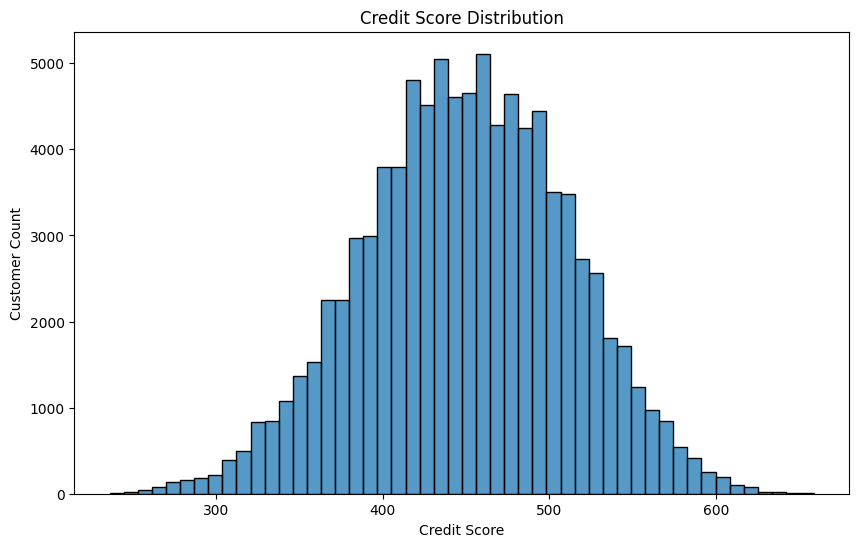

In [21]:
# ============================================================
# STEP 14 — SCORE DISTRIBUTION
# ============================================================

plt.figure(figsize=(10,6))

sns.histplot(
    test_score['score'],
    bins=50
)

plt.title("Credit Score Distribution")

plt.xlabel("Credit Score")

plt.ylabel("Customer Count")

plt.show()

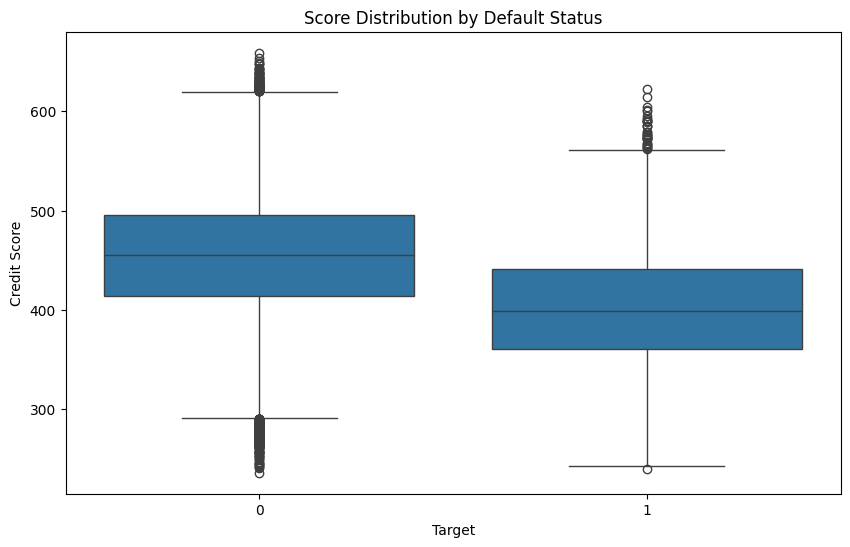

In [22]:
# ============================================================
# STEP 15 — SCORE VS TARGET
# ============================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x=test_score['TARGET'],
    y=test_score['score']
)

plt.title("Score Distribution by Default Status")

plt.xlabel("Target")

plt.ylabel("Credit Score")

plt.show()

In [23]:
# ============================================================
# STEP 16 — CREATE RISK BANDS
# ============================================================

test_score['RISK_BAND'] = pd.cut(
    test_score['score'],
    bins=[0, 500, 650, 850],
    labels=[
        'High Risk',
        'Medium Risk',
        'Low Risk'
    ]
)


In [24]:
# ============================================================
# STEP 17 — RISK BAND COUNTS
# ============================================================

test_score['RISK_BAND'].value_counts()

,count
RISK_BAND,
High Risk,72675
Medium Risk,19576
Low Risk,3


In [25]:
# ============================================================
# STEP 18 — DEFAULT RATE BY RISK BAND
# ============================================================

risk_analysis = test_score.groupby(
    'RISK_BAND'
)['TARGET'].mean()

print(risk_analysis)

RISK_BAND
High Risk      0.097035
Medium Risk    0.020229
Low Risk       0.000000
Name: TARGET, dtype: float64


/tmp/ipykernel_21317/3741810953.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_analysis = test_score.groupby(


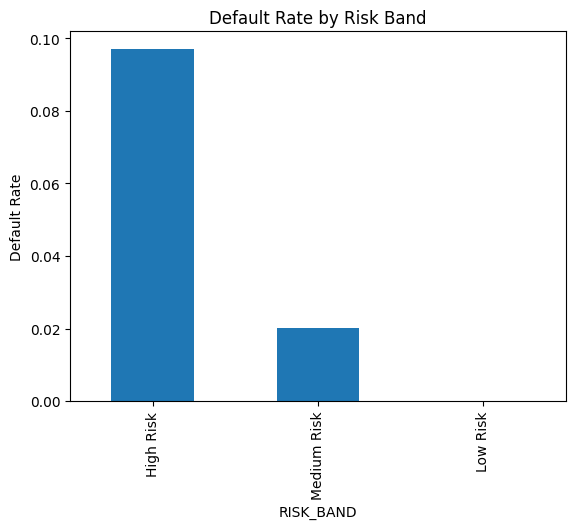

In [26]:
# ============================================================
# STEP 19 — VISUALIZE DEFAULT RATE
# ============================================================

risk_analysis.plot(
    kind='bar'
)

plt.title("Default Rate by Risk Band")

plt.ylabel("Default Rate")

plt.show()


In [27]:
# ============================================================
# STEP 20 — SAVE FINAL SCORES
# ============================================================

test_score.to_csv(
    '/content/customer_credit_scores.csv',
    index=False
)

print("Customer scores saved successfully")

Customer scores saved successfully


In [28]:
from google.colab import files
files.download('/content/customer_credit_scores.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>